### Build A Basic Chatbot With Langgraph(GRAPH API)"

In [107]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [108]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function",
    # in the annotation defines how this state key should be updated",
    # (in this case, it appends messages to the list, rather than overwriting them)"
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [109]:
graph_builder

In [110]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [111]:
from langchain_groq import ChatGroq
from langchain.chat_models import  init_chat_model

llm=ChatGroq(model="qwen/qwen3-32b")

In [112]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x114d2e120>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x114d158b0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [113]:
llm=init_chat_model("groq:qwen/qwen3-32b")

In [114]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x114d31880>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x114d339e0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [115]:
### Node functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [116]:
## add node
graph_builder.add_node("chatbot",chatbot)

## add edge
graph_builder.add_edge(START,"chatbot")

graph_builder.add_edge("chatbot",END)

## compile the graph

graph=graph_builder.compile()


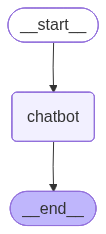

In [117]:
### Visualize the graph
from IPython.display import  Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [118]:
response=graph.invoke({"messages":"Hi"})
response["messages"][-1].content

'<think>\nOkay, the user sent "Hi". That\'s pretty casual. I should respond in a friendly and welcoming way. Let me make sure to acknowledge their greeting and offer assistance. Maybe something like, "Hello! How can I assist you today?" That keeps the door open for them to ask anything. I should keep it simple and not add too much unless they have a follow-up question. Just need to stay polite and helpful.\n</think>\n\nHello! How can I assist you today? 😊'

In [119]:
for event in graph.stream({"messages":"Hi how are you?"}):
    for value in event.values():
       print(value["messages"][-1].content)

<think>
Okay, the user just greeted me with "Hi how are you?" and I need to respond. Let me think about the right way to handle this.

First, the user is being friendly and asking about my well-being. Since I'm an AI, I don't experience feelings, but I should acknowledge their concern and respond warmly. I should keep it simple and positive. Maybe say something like "I'm doing well, thanks for asking! How can I assist you today?" That way, I thank them for their concern and pivot to how I can help, which keeps the conversation moving forward. 

I need to make sure the response is concise and not too wordy. Also, I should avoid any technical jargon and keep the tone friendly and approachable. Let me double-check if there's anything else to consider. No, that should cover it. The user might want to ask a question or need help with something specific, so ending with an offer to assist is good.
</think>

I'm doing well, thanks for asking! How can I assist you today? 😊


### Chatbot with tool

In [120]:
from langchain_tavily import TavilySearch

tool=TavilySearch(maz_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. By treating workflows as interconnected nodes and edges, LangGraph offers a scalable, transparent and developer-friendly way to design advanced AI systems ranging from simple chatbots to multi-agent system. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. By designing workflows, users combine multiple nodes into powerful, dynamic AI processes. * ****langgraph:**** Framework for build

In [121]:
### define custom function
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int

    Returns:
        output int
    """
    return a * b


In [122]:
tools=[tool,multiply]

In [123]:
llm_with_tool=llm.bind_tools(tools)

llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x114d31880>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x114d339e0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurat

### state graph

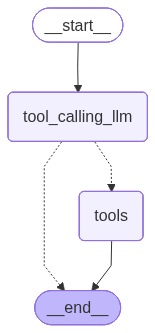

In [124]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edge
builder.add_edge(START,"tool_calling_llm"),
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools",
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END",
    tools_condition
)
builder.add_edge("tools",END)

##comile the graph

graph=builder.compile()


### Visualize the graph
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [125]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [126]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/202251-figma-adds-ai-agent-to-its-design-platform.html", "title": "Фигма ўзининг дизайн платформасига сунъий интеллект агентини қўшди - Zamin.uz", "score": 0.97754294, "published_date": "Wed, 20 May 2026 13:27:19 GMT", "content": "# Figma adds AI agent to its design platform. In recent months, Figma has partnered with OpenAI and Anthropic, enabling users to leverage coding environments like Claude Code and Codex alongside its design software. Now, the company has introduced a new AI agent that operates within its collaborative canvas. The company emphasizes that this AI assistant understands design context and elements well, as it is powered by AI models specifically tailored for the design industry. The new agent will initially launch on the Figma Design platform and will be integrated into the company\'s other products in the future. Despite conc

In [127]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (f29h3av8e)
 Call ID: f29h3av8e
  Args:
    query: recent AI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/202251-figma-adds-ai-agent-to-its-design-platform.html", "title": "Фигма ўзининг дизайн платформасига сунъий интеллект агентини қўшди - Zamin.uz", "score": 0.97754294, "published_date": "Wed, 20 May 2026 13:27:19 GMT", "content": "# Figma adds AI agent to its design platform. In recent months, Figma has partnered with OpenAI and Anthropic, enabling users to leverage coding environments like Claude Code and Codex alongside its design s

In [128]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (00mq3pk9h)
 Call ID: 00mq3pk9h
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [129]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (kvt9p0bh5)
 Call ID: kvt9p0bh5
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (tr0pp3z61)
 Call ID: tr0pp3z61
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/05/22/ai-tech-brief-tech-ceos-blocked-executive-order/", "title": "AI & Tech Brief: Tech CEOs blocked executive order - The Washington Post", "score": 0.67501575, "published_date": "Fri, 22 May 2026 19:00:04 GMT", "content": "AI & Tech Brief from WP Intelligence. # AI & Tech Brief: Tech CEOs blocked executi

### ReAct Agent Architecture

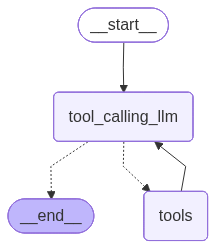

In [130]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [131]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (85hhsfszs)
 Call ID: 85hhsfszs
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: general
  multiply (m24ybzeb5)
 Call ID: m24ybzeb5
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.yeschat.ai/gpts-9t557fXdeRL-Recent-AI-News", "title": "Recent AI News-Free, Customized AI Updates", "content": "Title: Recent AI News-Free, Customized AI Updates\n# Recent AI News- Customized AI Updates. Welcome to Recent AI News! ## Overview of Recent AI News. Recent AI News is designed as an expert GPT aimed at keeping users en

In [132]:
## Adding Memory In Agentic Graph

In [133]:
response=graph.invoke({"messages":"Hello my name is Milan"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Milan
================================== Ai Message ==================================

Hi Milan! How can I assist you today?


In [134]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have access to personal information about users. If you'd like me to address you by name, please share it with me directly!


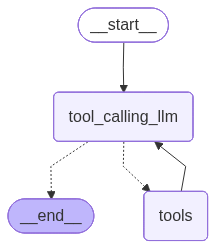

In [135]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [136]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Milan"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Milan', additional_kwargs={}, response_metadata={}, id='bf54434c-5c9e-4c8d-b231-c3bc108ae4bd'),
  AIMessage(content='Hello, Milan! How can I assist you today? 😊', additional_kwargs={'reasoning_content': 'Okay, the user said, "Hi my name is Milan." I need to respond appropriately. Let me see. First, this is a greeting, so I should greet them back. They provided their name, so I should acknowledge that. Since there\'s no specific question here, I don\'t need to use any of the tools like tavily_search or multiply. My response should be friendly and invite them to ask for help if needed. Let me make sure I\'m not missing any hidden queries. Nope, it\'s just a simple introduction. So, the best reply is to say hello, mention their name, and offer assistance. Keep it natural and welcoming.\n'}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 1786, 'total_tokens': 1937, 'completion_time': 0.305833484, 'completion_t

In [137]:
response['messages'][-1].content

'Hello, Milan! How can I assist you today? 😊'

In [138]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Milan. 😊 Let me know how I can assist you!


In [139]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes, I remember your name is Milan! 😊 How can I assist you today?


### Streaming

In [140]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [141]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

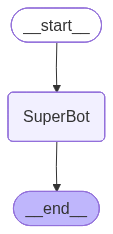

In [142]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [143]:
## Invocation

config = {"configurable": {"thread_id": "01"}}

graph_builder.invoke({'messages':"Hi,My name is Milan And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Milan And I like cricket', additional_kwargs={}, response_metadata={}, id='7ff63839-ae7e-41fe-9174-55b087aa7595'),
  AIMessage(content="<think>\nOkay, the user is Milan and he likes cricket. Let me see how to respond appropriately. First, I should greet him and acknowledge his interest in cricket. Maybe ask him how he started playing. I need to keep it friendly and open-ended. Also, maybe mention something about the game to keep the conversation going. Let me check if there are any recent cricket events I can reference. Oh, the T20 World Cup is coming up, that could be a good topic. I should make sure not to use any jargon he might not understand. Keep it simple and welcoming. Alright, let's put it all together.\n</think>\n\nHello Milan! Nice to meet you! 🏏 I love that you're into cricket—it's such a thrilling game. Do you play it yourself, or are you more of a passionate spectator? I'd also love to hear what aspects of the game you enj

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [145]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Milan And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user just introduced themselves as Milan and mentioned they like cricket. I need to respond appropriately. First, acknowledge their name and interest. Maybe ask a follow-up question to keep the conversation going. Let me check the previous response to avoid repetition.\n\nHmm, in the first response, I said Hello Milan and asked about their favorite team. Now, since the user hasn't answered that yet, I should prompt them again. Wait, the user's latest message is the same as the first one. Did they maybe send it twice by mistake? Or is this a new interaction? Wait, looking at the history, the user sent the same message again. Maybe they intended to continue the conversation but just repeated the intro. \n\nI should respond warmly, confirm their name, and ask about their favorite team again. Also, maybe add a friendly emoji to keep it engaging. Let me make sure the response is clear and encouraging. No markdown, just plain t

In [146]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Milan And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Milan And I like cricket', additional_kwargs={}, response_metadata={}, id='79b07ee9-4cd8-4c12-a308-c3b9fc16c20a'), HumanMessage(content='Hi,My name is Milan And I like cricket', additional_kwargs={}, response_metadata={}, id='c211e061-6d34-492b-a15c-de45269d62dc'), AIMessage(content="<think>\nOkay, the user just introduced themselves as Milan and mentioned they like cricket. I need to respond appropriately. First, acknowledge their name and interest. Maybe ask a follow-up question to keep the conversation going. Let me check the previous response to avoid repetition.\n\nHmm, in the first response, I said Hello Milan and asked about their favorite team. Now, since the user hasn't answered that yet, I should prompt them again. Wait, the user's latest message is the same as the first one. Did they maybe send it twice by mistake? Or is this a new interaction? Wait, looking at the history, the user sent the same message again. Maybe they int

In [147]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Milan And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user is Milan and he likes cricket. I should respond in a friendly way. Let me greet him first and acknowledge his interest in cricket. Maybe ask him some questions to engage in a conversation. I can mention cricket topics like his favorite team, player, or what he enjoys about the game. Keep the tone positive and open-ended to encourage him to share more. Make sure to use proper punctuation and friendly language.\n</think>\n\nHi Milan! Nice to meet you! 🏏 I'm glad you mentioned cricket—my favorite sport too! Do you have a favorite team or player? I'd love to hear what you enjoy most about the game. Maybe we can chat about some exciting matches or even discuss the IPL if you're into that! 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 18, 'total_tokens': 175, 'completion_time': 0.374061433, 'completion_tokens_details': None, 'prompt_time': 0.000716393, 'prompt_token

In [148]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Milan And I like cricket', additional_kwargs={}, response_metadata={}, id='28262e2a-d261-4cdd-bb72-7301cba51c78'), AIMessage(content="<think>\nOkay, the user is Milan and he likes cricket. I should respond in a friendly way. Let me greet him first and acknowledge his interest in cricket. Maybe ask him some questions to engage in a conversation. I can mention cricket topics like his favorite team, player, or what he enjoys about the game. Keep the tone positive and open-ended to encourage him to share more. Make sure to use proper punctuation and friendly language.\n</think>\n\nHi Milan! Nice to meet you! 🏏 I'm glad you mentioned cricket—my favorite sport too! Do you have a favorite team or player? I'd love to hear what you enjoy most about the game. Maybe we can chat about some exciting matches or even discuss the IPL if you're into that! 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_toke

In [149]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e5514-74b4-7250-9ab7-d2d4a0c247dc', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='8db9ed5b-aada-4599-a1ed-3d4b118ccb5c')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019e5514-74b6-7170-b09c-6725b07fdab4', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:866720fb-49c8-470a-200f-90cca4450df8'}, 'parent_ids': ['019e5514-74b4-7250-9ab7-d2d4a0c247dc']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':